tde_sim_50k_t_fix400_725.csv
ground_truth_50k_t_fix400_725.csv
x=[
    0.16,   # 0 compressive power
    32,   # 1 bound of tied
    1.1,     # 2 t0
    35,   # 3 tse_tied
    30,      # 7 t_motor
    0.10,      # 4 pa drift
    80,      # 5 pa bound
    -20,      # 6 tse_pa
    0, # 8 delta
    0.005,    # 9 b
    0.05,      # 10 c
    1,   # 11 d
    100,   # 12 e
    0.6,   # 13 f
    40,   # 14 g
False,True]

[ 0.1641666 32.3287044  0.948705 ] [ 0.12659927 90.6140987 ] [ 34.0242664  40.2       -20.       ] [0.00304154 0.07428961 0.99999999] [100.    0.6  40. ]
-13867.45714230312
-14561.556212372807
-13867.45714230312


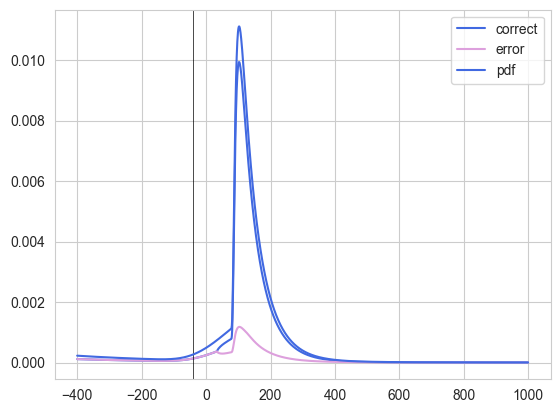

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import erfcx
from ana_rtd_comp import ana_rtd
from ana_acc_comp import ana_acc
import pandas as pd
from scipy.special import erfc
import seaborn as sns
import ast
from pybads import BADS
import numpy as np
import matplotlib.pyplot as plt
from model_TDE_delta_724 import model_TDE

tt = np.arange(-400, 1000, 1)
abl = 40
ild = 4
out = 1.0
t_fix=400
x= [1.64166597e-01, 3.23287044e+01, 0.9487050, 3.40242664e+01,40.2, \
     1.26599271e-01, 9.06140987e+01,-20, -40,
     3.04154113e-03, 7.42896109e-02, 9.99999994e-01,100,0.6,40, False, True]
# x = [compressive_power, a_tied, T0, ndt, v, a,pa_ndt, w_tse, Delta,b,c,d]
model = model_TDE(RT=tt, ABL=abl * np.ones_like(tt), ILD=ild * np.ones_like(tt), t_fix=t_fix * np.ones_like(tt),out=1.0 * np.ones_like(tt))
model.set_params(x)
model.print_params()

logL_corr, logL_err = model.log_likelihood_both()
print(np.sum(logL_corr))
print(np.sum(logL_err))

logL = model.log_likelihood()
print(np.sum(logL))
pdf_a, tach = model.pdf_and_tach()

plt.plot(tt, pdf_a * tach, label='correct', color='royalblue')
plt.plot(tt, pdf_a * (1 - tach), label='error', color='plum')
plt.axvline(-40, color='black', lw=0.5)
plt.plot(tt, pdf_a, label='pdf', color='royalblue')
plt.legend()
plt.show()

In [7]:
tt= np.arange(-400, 1000, 1)
tde= model.TDE_values(tt)

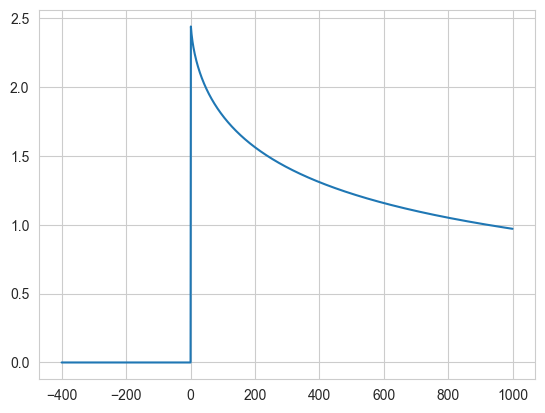

In [8]:
plt.plot(tt, tde, label='TDE')

In [3]:

df = pd.read_csv('/Users/utsai/Desktop/short_dur/csv doc/tde_sim_50k_t_fix400_725.csv')
df['|ILD|'] = df['ILD'].abs()
df = df[
    (df['RT']<1000)
]

In [4]:

def total_log_likelihood(data, params):
    rt_vect = np.array(data['RT'])
    abl_vect = np.array(data['ABL'])
    ild_vect = np.array(data['|ILD|'])
    fix_vect = np.array(data['t_fix'])
    out_vect = np.array(data['success'])
    model = model_TDE(RT=rt_vect, ABL=abl_vect, ILD=ild_vect, t_fix=fix_vect, out=out_vect)
    params.insert(12, 100)
    params.insert(14, 100)
    model.set_params(params)
    logL = model.log_likelihood()
    return np.sum(logL)


def objective_function(params, data):
    """ 
    Compute the negative log-likelihood for the DDM parameters.
    
    :param params: array of model parameters [v, a, x1, x2, x3, x4]
    :param data: DataFrame with the experimental data
    :return: Negative log-likelihood

    """  # Assuming x includes 4 parameters
    x = [*params,False, True]
    # Calculate the total log likelihood using the defined function
    total_likelihood = total_log_likelihood(data, x)
    # BADS minimizes the function, so return negative log likelihood
    return -total_likelihood


#creat a suitable function for bads

def objective_fun_forbads(params):
    data = df
    return objective_function(params, data)


# x = [compressive_power, a_tied, T0, tse_tied,tmotor, v, a,tse_pa, Delta,b,c,d,e,f]
lower_bounds = [0.03, 10, 0.05,0, 0,  0,   0,   -150,-10, 0.0001,0,    0,   1,  0]  # Hard lower bounds
upper_bounds = [0.5,  80, 4,   80,80, 1,   150, 50,  120, 0.1,   1,    1,   10, 1]  # Hard upper bounds
plausible_lb = [0.04, 15, 0.1, 10,10, 0.02,10,  -100,0,   0.0002,0.01, 0.5, 1.2,0.1]  # Plausible lower bounds
plausible_ub = [0.4,  60, 1.8, 50,50, 0.8, 80,  30,  70,  0.08,  0.5,  0.9, 8,  0.8] 


num_initial_guesses = 10
initial_param_sets = np.random.uniform(low=plausible_lb, high=plausible_ub, size=(num_initial_guesses, len(plausible_lb)))
initial_param_sets = initial_param_sets.tolist()
# Run optimization for each animal
all_results = []
best_result = None
row_count = len(df)
for i, initial_params in enumerate(initial_param_sets):
    print(f"Starting optimization with initial params: {initial_params}")
    bads = BADS(objective_fun_forbads, initial_params, lower_bounds, upper_bounds, plausible_lb, plausible_ub)
    optimize_result = bads.optimize()
    result_details = {
        'initial_params': str(initial_params),
        'optimized_params': str(optimize_result.x),
        'result_fun': optimize_result.fval,
        'row_count': row_count,
        'is_best': 0  # Default to 0, will update later if it's the best
    }
    print(f"Optimization result: {optimize_result.x}, {optimize_result.fval}")
    all_results.append(result_details)

    # Update the best result if it's the first run or better than the previous best
    if best_result is None or optimize_result.fval < best_result.fval:
        best_result = optimize_result
        best_params = initial_params

# Update the best result indicator for the best optimization run
for result in all_results:
    if result['initial_params'] == str(best_params):
        result['is_best'] = 1

# Convert all_results to a DataFrame
results_df = pd.DataFrame(all_results)
results_df.to_csv('delta_3delays_GT_recovery_712.csv', index=False)


Starting optimization with initial params: [0.2969923868946336, 52.940144760332025, 0.5310458899389757, 14.208760517124226, 21.83864470072819, 0.28600998075038214, 67.25015673030725, -48.566307012714965, 11.244924312743892, 0.04686801823027707, 0.38339753028499707, 0.4562109738006116, 0.9321189601200424, 71.69637085940441]
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
Variables (index) internally transformed to log coordinates: [[0 0]
 [0 2]
 [0 9]]
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2          487297               1                                 Uncertainty test


/Users/utsai/Desktop/short_dur/model_TDE_delta_724.py:340: RuntimeWarning: divide by zero encountered in divide
  tach = np.where(inds0,pr[indsnot0][-1],pr/(1-FS))


     0          18          372522               1         Initial mesh            Initial points


/Users/utsai/Desktop/short_dur/model_TDE_delta_724.py:340: RuntimeWarning: invalid value encountered in divide
  tach = np.where(inds0,pr[indsnot0][-1],pr/(1-FS))


     0          36          341670               1       Successful poll           Train
     1          38          336086               1     Successful search (ES-ell)        
     1          39          334637               1     Successful search (ES-ell)        


KeyboardInterrupt: 

In [ ]:
def fix_params(param_str):
    # Inserts commas to create a valid list string from the parameters from csv.
    # Splits the string on spaces, filters out empty elements, joins them back with commas
    fixed_str = '[' + ','.join(param_str.strip('[]').split()) + ']'
    return ast.literal_eval(fixed_str)

# Load the results DataFrame
results_df = pd.read_csv('delta_3delays_GT_recovery_712.csv')

optimized_params = {}
for index, row in results_df.iterrows():
    optimized_param = fix_params(row['optimized_params'])
    optimized_params[index]= optimized_param

In [ ]:
ground_truth=[
    0.16,   # 0 compressive power
    32,   # 1 bound of tied
    0.2,     # 2 t0
    35,   # 3 tse_tied
    30,      # 7 t_motor
    0.10,      # 4 pa drift
    80,      # 5 pa bound
    -20,      # 6 tse_pa
    30, # 8 delta
    0.005,    # 9 b
    0.05,      # 10 c
    1,   # 11 d
    2,   # 12 e
    0.5,   # 13 f
    ]

In [ ]:

initial_params = results_df['initial_params'].apply(eval).tolist()
# Convert to DataFrame for easier manipulation
initial_params_df = pd.DataFrame(initial_params, columns=[
    'comp power', 'TIED bound', 't0', 'tied_tse','t_motor', 'pa drift', 'a bound', 'pa_tse', 
     'delta', 'b', 'c', 'd','e','f'])
optimized_params_df = pd.DataFrame.from_dict(optimized_params, orient='index', columns=[
    'comp power', 'TIED bound', 't0', 'tied_tse','t_motor', 'pa drift', 'a bound', 'pa_tse', 
     'delta', 'b', 'c', 'd','e','f'])
fig, axes = plt.subplots(2, 7, figsize=(42, 12))
fig.suptitle('Initial Guess vs Fitted Parameters')

param_names = ['comp power', 'TIED bound', 't0', 'tied_tse','t_motor', 'pa drift', 'a bound', 'pa_tse', 
     'delta', 'b', 'c', 'd','e','f']
# Plot each parameter
for i, ax in enumerate(axes.flat):
    param_name = param_names[i]
    ax.scatter(initial_params_df[param_name], optimized_params_df[param_name])
    ax.axhline(y=ground_truth[i], color='r', linestyle='--', label=f'Ground Truth ({ground_truth[i]})')
    ax.set_xlabel(f'Initial {param_name}', fontsize=20)
    ax.set_ylabel(f'Fitted {param_name}', fontsize=20)
    ax.set_title(f'Param {param_name}', fontsize=20)
    if ground_truth[i]>0:
        ax.set_ylim(ground_truth[i]*0.5,ground_truth[i]*2)
    else:
        ax.set_ylim(ground_truth[i]*5,ground_truth[i]*0.2)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [ ]:
correlation_matrix = optimized_params_df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={"shrink": .8})
plt.title('Pairwise Pearson Correlation Matrix of Parameters')
plt.show()

In [9]:
def TDE_value_new(alpha,lambda_,t):
    musk1=t>0
    p = np.zeros(len(t))
    p[musk1]= 1/((t[musk1]+alpha)**lambda_)+1-alpha**(-lambda_)
    return p

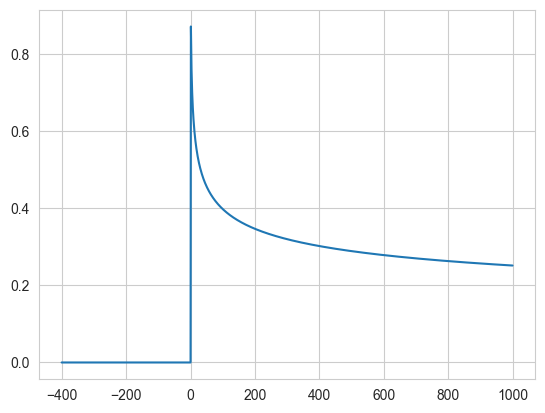

In [41]:
tt = np.arange(-400, 1000, 1)
p= TDE_value_new(1, 0.2, tt)
plt.plot(tt, p)